In [11]:
# =========================
# Data I/O and preparation
# =========================
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Keep your seaborn styling (customize if you already set rcParams/theme earlier)
sns.set_theme()

RESULTS_DIR = Path("results")  # adjust if your structure differs
ALGO_DIR_GLOBS = ["*"]         # or list specific algo dir names to restrict

CSV_FILES = {
    "rome": "rome_filtered.csv",
    "extended_BA": "extended_BA_filtered.csv",
}
METRIC_COLS = ["GCN", "LCN"]
REQUIRED_COLS = ["instance", "solved", "time", "GCN", "LCN", "stress"]

def _read_single_csv(csv_path: Path, algo_name: str, dataset: str) -> pd.DataFrame:
    """Read one CSV and attach algo/dataset labels; enforce required columns."""
    df = pd.read_csv(csv_path, sep=";")
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"{csv_path} is missing columns: {missing}")
    df["algo"] = algo_name
    df["dataset"] = dataset
    return df

def load_results(results_dir: Path = RESULTS_DIR,
                 datasets=("rome", "extended_BA"),
                 algo_globs=ALGO_DIR_GLOBS) -> pd.DataFrame:
    """
    Scan results/<algo>/{rome_filtered.csv,extended_BA_filtered.csv},
    read, label, and concatenate into one tidy DataFrame.
    """
    frames = []
    for algo_dir in sum([list((results_dir).glob(g)) for g in algo_globs], []):
        if not algo_dir.is_dir():
            continue
        algo_name = algo_dir.name
        for dset in datasets:
            csv_name = CSV_FILES[dset]
            csv_path = algo_dir / csv_name
            if csv_path.exists():
                frames.append(_read_single_csv(csv_path, algo_name, dset))
    if not frames:
        raise FileNotFoundError("No CSVs found. Check RESULTS_DIR and folder layout.")
    df = pd.concat(frames, ignore_index=True)

    # Canonicalize types
    df["solved"] = df["solved"].astype(int)
    df["time"] = pd.to_numeric(df["time"], errors="coerce")
    for m in METRIC_COLS:
        df[m] = pd.to_numeric(df[m], errors="coerce")

    # Useful derived flags
    df["finished"] = df["solved"] == 1
    return df

def filter_data(df: pd.DataFrame,
                dataset: str | None = None,
                require_finished: bool = True) -> pd.DataFrame:
    """Filter by dataset and whether runs finished."""
    g = df
    if dataset is not None:
        if dataset not in CSV_FILES:
            raise ValueError(f"dataset must be one of {list(CSV_FILES)}, got {dataset}")
        g = g[g["dataset"] == dataset]
    if require_finished:
        g = g[g["finished"]]
    return g.copy()

def to_long_metrics(df: pd.DataFrame, metrics=METRIC_COLS) -> pd.DataFrame:
    """
    Long (tidy) view: one row per (instance, algo, dataset, metric).
    Keeps time in the same row for joint plotting/faceting if desired.
    """
    long = df.melt(
        id_vars=["instance", "algo", "dataset", "time", "finished", "solved", "stress"],
        value_vars=[m for m in metrics if m in df.columns],
        var_name="metric",
        value_name="value"
    )
    return long


# =========================
# Summary helpers
# =========================
def per_algo_summary(df: pd.DataFrame, metric: str = "GCN") -> pd.DataFrame:
    """
    Aggregate per algorithm on the chosen metric + time.
    """
    if metric not in METRIC_COLS:
        raise ValueError(f"metric must be one of {METRIC_COLS}, got {metric}")
    agg = (
        df.groupby(["dataset", "algo"], as_index=False)
          .agg(
              n=("instance", "count"),
              solved_rate=("finished", "mean"),
              time_mean=("time", "mean"),
              time_median=("time", "median"),
              metric_mean=(metric, "mean"),
              metric_median=(metric, "median")
          )
    )
    return agg


# =========================
# Plotting utilities
# =========================
def plot_metric_box(df: pd.DataFrame,
                    metric: str = "GCN",
                    dataset: str | None = None,
                    order=None,
                    showfliers=False,
                    ax=None):
    """
    Boxplot of metric per algorithm for a dataset; hides fliers by default.
    """
    g = filter_data(df, dataset=dataset, require_finished=True)
    if metric not in METRIC_COLS:
        raise ValueError(f"metric must be one of {METRIC_COLS}, got {metric}")

    ax = ax or plt.gca()
    sns.boxplot(
        data=g, x="algo", y=metric, order=order, showfliers=showfliers, ax=ax
    )
    ax.set_title(f"{metric} per algorithm" + (f" — {dataset}" if dataset else ""))
    ax.set_xlabel("Algorithm")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=45)
    return ax

def plot_metric_violin(df: pd.DataFrame,
                       metric: str = "GCN",
                       dataset: str | None = None,
                       inner="quartile",
                       scale="width",
                       ax=None):
    """
    Violin alternative for distribution comparison.
    """
    g = filter_data(df, dataset=dataset, require_finished=True)
    if metric not in METRIC_COLS:
        raise ValueError(f"metric must be one of {METRIC_COLS}, got {metric}")

    ax = ax or plt.gca()
    sns.violinplot(
        data=g, x="algo", y=metric, inner=inner, scale=scale, cut=0, ax=ax
    )
    ax.set_title(f"{metric} per algorithm" + (f" — {dataset}" if dataset else ""))
    ax.set_xlabel("Algorithm")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=45)
    return ax

def plot_time_box(df: pd.DataFrame,
                  dataset: str | None = None,
                  logy: bool = True,
                  showfliers=False,
                  ax=None):
    """Runtime distribution per algorithm."""
    g = filter_data(df, dataset=dataset, require_finished=True)

    ax = ax or plt.gca()
    sns.boxplot(data=g, x="algo", y="time", showfliers=showfliers, ax=ax)
    if logy:
        ax.set_yscale("log")
    ax.set_title("Runtime per algorithm" + (f" — {dataset}" if dataset else ""))
    ax.set_xlabel("Algorithm")
    ax.set_ylabel("time [s]")
    ax.tick_params(axis="x", rotation=45)
    return ax

def plot_metric_vs_time(df: pd.DataFrame,
                        metric: str = "GCN",
                        dataset: str | None = None,
                        hue: str = "algo",
                        jitter: float = 0.0,
                        alpha: float = 0.7,
                        ax=None):
    """
    Scatter of metric vs runtime; useful to see quality-speed tradeoffs.
    """
    g = filter_data(df, dataset=dataset, require_finished=True)
    if metric not in METRIC_COLS:
        raise ValueError(f"metric must be one of {METRIC_COLS}, got {metric}")

    ax = ax or plt.gca()
    # Optional jitter on x if you facet by metric; here x is time
    data = g.copy()
    if jitter:
        import numpy as np
        data["time"] = data["time"] * (1 + np.random.uniform(-jitter, jitter, size=len(data)))

    sns.scatterplot(
        data=data, x="time", y=metric, hue=hue, ax=ax
    )
    ax.set_xscale("log")
    ax.set_title(f"{metric} vs time" + (f" — {dataset}" if dataset else ""))
    ax.set_xlabel("time [s] (log)")
    ax.set_ylabel(metric)
    ax.grid(True, which="both", axis="x")
    return ax


# =========================
# Convenience wrappers
# =========================
def make_all_plots(df: pd.DataFrame, dataset: str):
    """
    Produce a small gallery consistent with your existing notebook:
    - boxplot for metric GCN
    - boxplot for metric LCN
    - runtime box
    - metric vs time scatter (for GCN)
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
    plot_metric_box(df, metric="GCN", dataset=dataset, ax=axes[0, 0])
    plot_metric_box(df, metric="LCN", dataset=dataset, ax=axes[0, 1])
    plot_time_box(df, dataset=dataset, ax=axes[1, 0])
    plot_metric_vs_time(df, metric="GCN", dataset=dataset, ax=axes[1, 1])
    return fig, axes


             instance  solved      time   GCN   LCN  stress     algo dataset  \
0   grafo11072.98.gml       1  355.5932  70.0   7.0  0.6218  edgeins    rome   
1   grafo11085.97.gml       1   41.3766   8.0   3.0  0.6375  edgeins    rome   
2  grafo11093.100.gml       1  118.7266  23.0   5.0  0.6499  edgeins    rome   
3   grafo11099.99.gml       1  567.5914  99.0  11.0  0.6405  edgeins    rome   
4   grafo11128.36.gml       1    5.9205   5.0   2.0  0.5555  edgeins    rome   

   finished  
0      True  
1      True  
2      True  
3      True  
4      True  


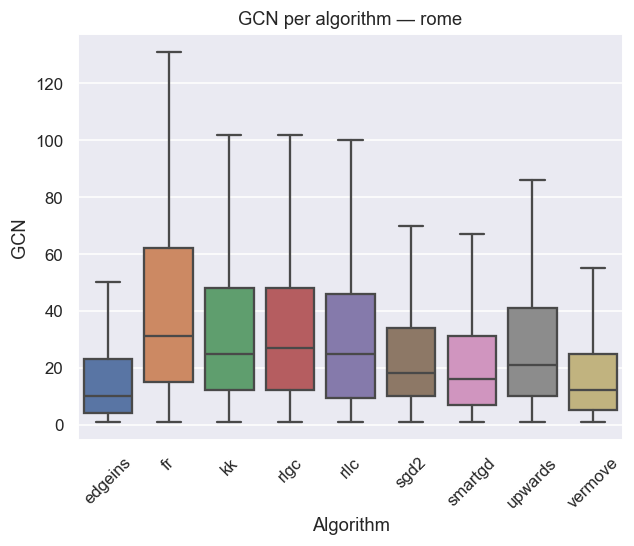

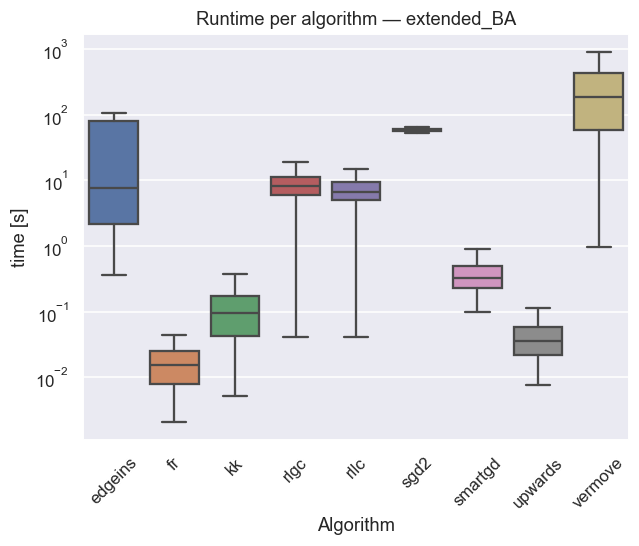

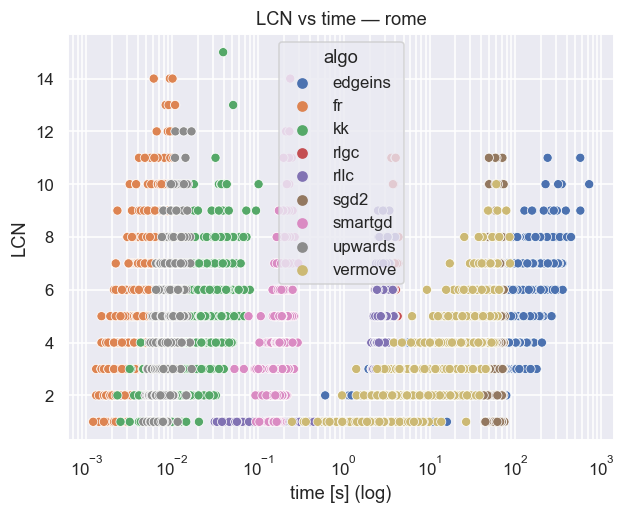

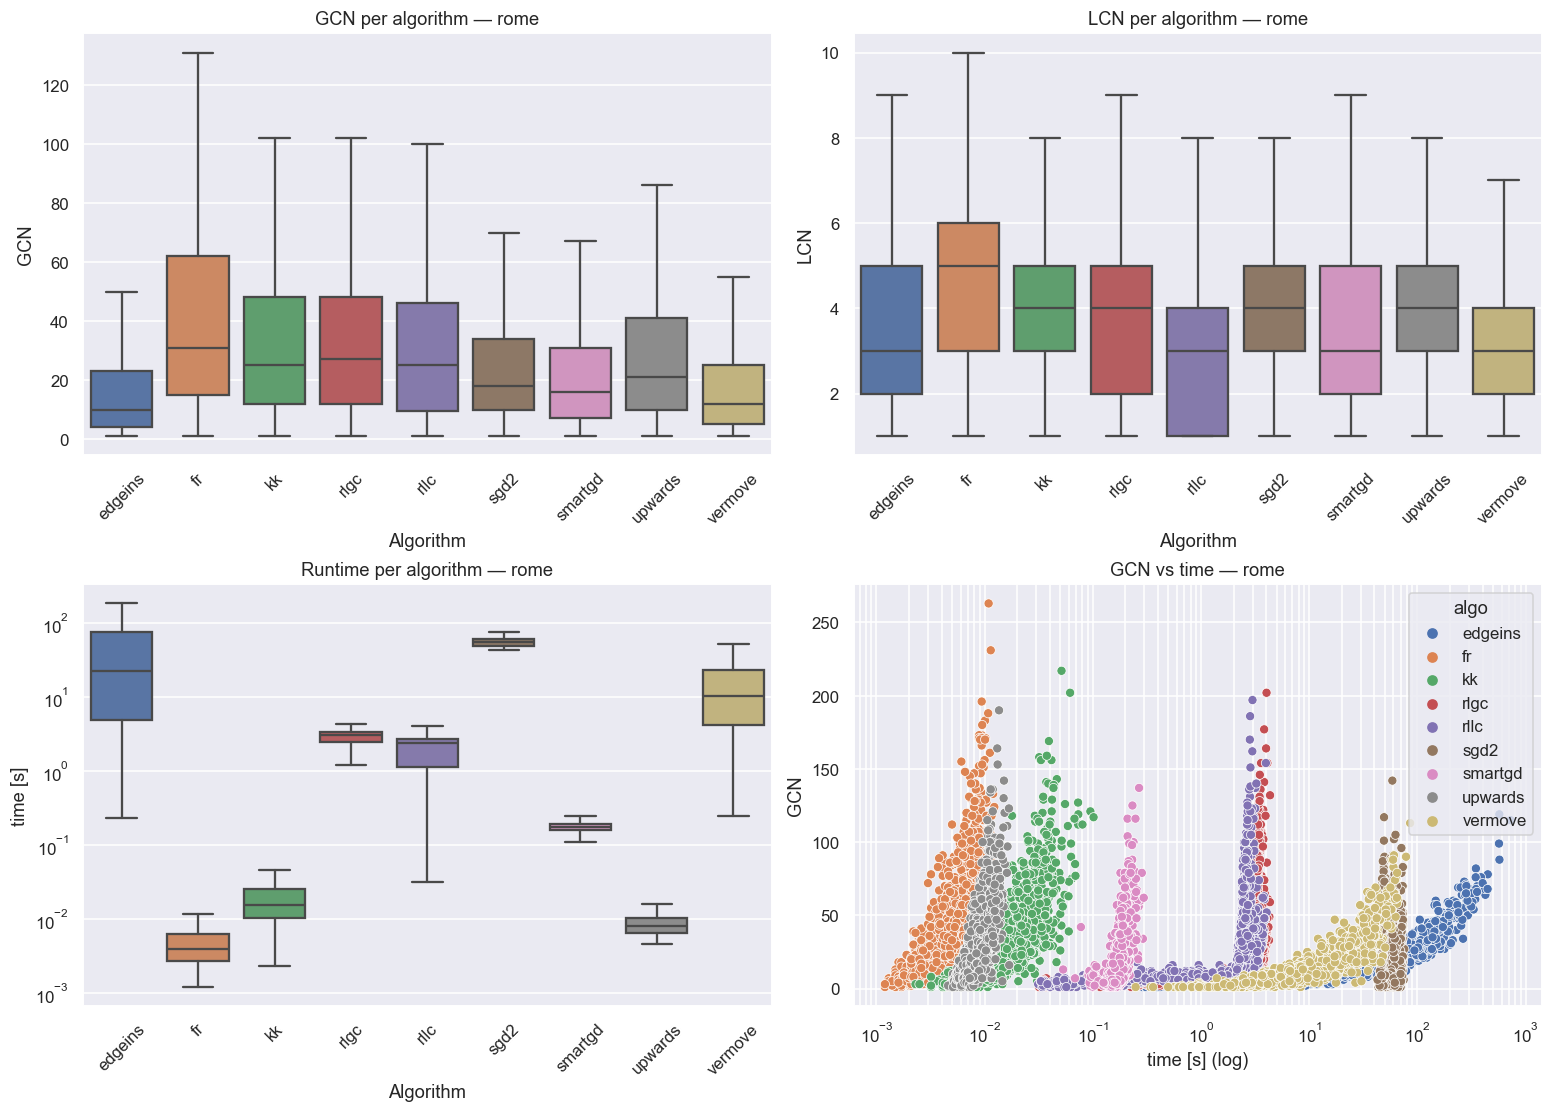

In [12]:
df_all = load_results()                       # reads everything under results/<algo>/
df_rome = filter_data(df_all, "rome")         # finished-only by default
df_ext  = filter_data(df_all, "extended_BA")

# print(df_rome.head())

# Quick summaries
per_algo_summary(df_rome, metric="GCN")
per_algo_summary(df_ext,  metric="LCN")

# Plots
_ = plot_metric_box(df_all, metric="GCN", dataset="rome")
plt.show()

_ = plot_time_box(df_all, dataset="extended_BA", logy=True)
plt.show()

_ = plot_metric_vs_time(df_all, metric="LCN", dataset="rome")
plt.show()

# Gallery
make_all_plots(df_all, dataset="rome")
plt.show()
